<a href="https://colab.research.google.com/github/gyumin125/25-2-DIP-202302456/blob/main/HW/HW07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.ndimage as nd
from PIL import Image

In [2]:
from google.colab import drive
drive.mount('/content/drive')
imgpath = '/content/drive/MyDrive/DIP4E'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Exercise
- 각자 준비한 사진을 불러와서 관심있는 대상의 숫자를 셀 수 있는 알고리즘을 morphological processing을 기반으로 구현해보자.
- 배운 내용들을 적절하게 활용하여 개수를 세는 알고리즘의 정확도를 높여보자.

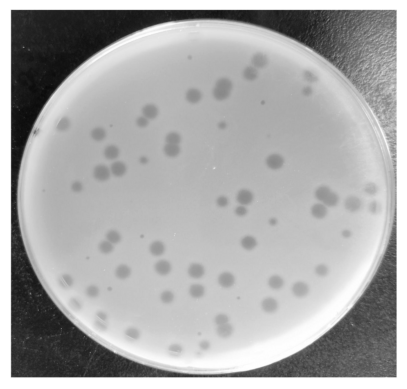

In [3]:
f = Image.open('plaque counting.png').convert('L')
f = np.array(f)
plt.imshow(f,cmap='gray')
plt.axis('off')
plt.show()

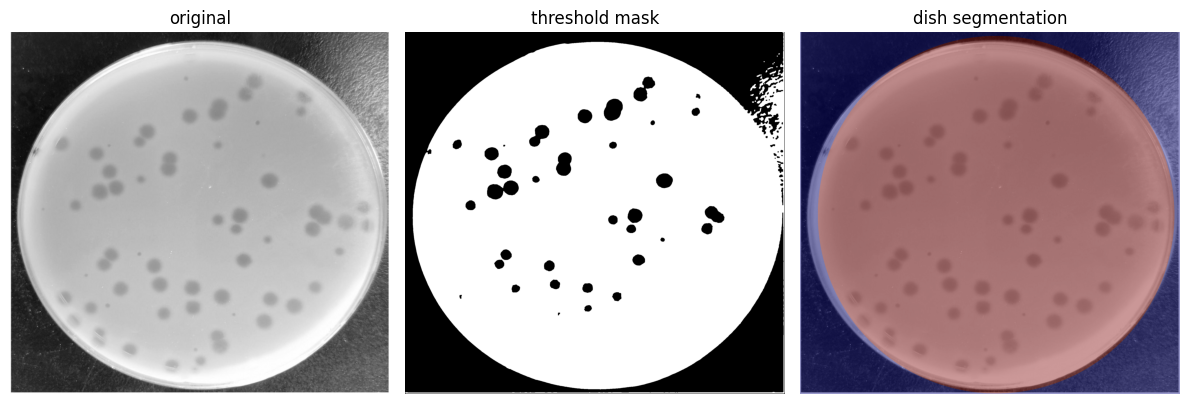

In [4]:


g = np.array(f).astype(np.uint8)
g_blur = nd.gaussian_filter(g, sigma=2)

T = np.mean(g_blur)
dish_candidate = g_blur > T

dish_candidate = nd.binary_closing(dish_candidate, structure=np.ones((5,5)))
dish_candidate = nd.binary_opening(dish_candidate, structure=np.ones((5,5)))
dish_filled = nd.binary_fill_holes(dish_candidate)


ys, xs = np.nonzero(dish_filled)
cy, cx = ys.mean(), xs.mean()

dist = np.sqrt((ys - cy)**2 + (xs - cx)**2)
r = np.percentile(dist, 95)

H, W = dish_filled.shape
yy, xx = np.indices((H, W))
circle_mask = ((yy - cy)**2 + (xx - cx)**2) <= r**2

dish_mask = circle_mask

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(g, cmap='gray')
plt.title("original")
plt.axis('off')

plt.subplot(132)
plt.imshow(dish_candidate, cmap='gray')
plt.title("threshold mask")
plt.axis('off')

plt.subplot(133)
plt.imshow(g, cmap='gray')

plt.imshow(dish_mask, cmap='jet', alpha=0.4)
plt.title("dish segmentation")
plt.axis('off')

plt.tight_layout()
plt.show()


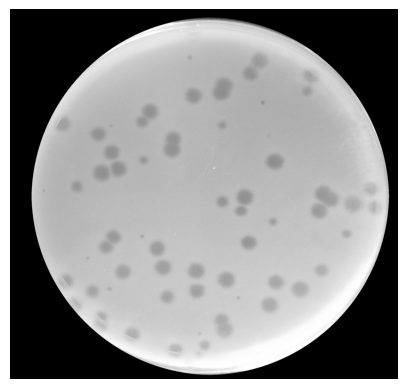

In [5]:
inner_mask = nd.binary_erosion(dish_mask, structure=np.ones((35, 35)))
g_inside=g*inner_mask
plt.imshow(g_inside,cmap='gray')
plt.axis('off')
plt.show()

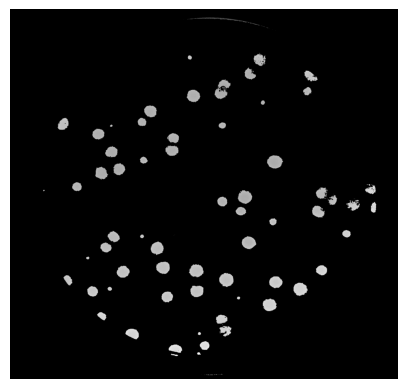

In [6]:

g_i = g_inside.astype(np.int16)
bg  = nd.gaussian_filter(g_i, sigma=30)

enh = bg - g_i
enh[~inner_mask] = 0

mask = (enh > 10) & inner_mask
g_seg = g_inside * mask

plt.imshow(g_seg, cmap='gray')
plt.axis('off')
plt.show()


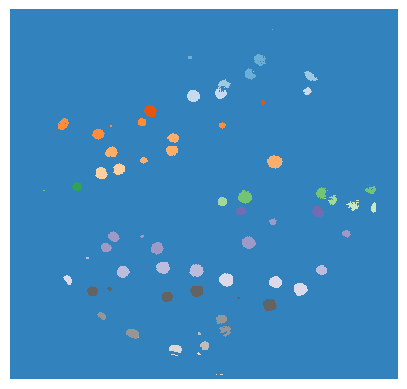

  244개가 맞나요?


In [7]:
l, m = nd.label(g_seg)
plt.imshow(l,interpolation='nearest',cmap='tab20c')
plt.axis('off')
plt.show()
print(f'  {m}개가 맞나요?')

In [8]:
cc = np.zeros((m-1,2))
for i in range(1,m):
  cc[i-1,0] = i
  cc[i-1,1] = np.sum(l==i)
  print(f'index: {int(cc[i-1,0])}, number of pixels: {int(cc[i-1,1])}')

index: 1, number of pixels: 1504
index: 2, number of pixels: 6
index: 3, number of pixels: 1
index: 4, number of pixels: 156
index: 5, number of pixels: 6
index: 6, number of pixels: 2
index: 7, number of pixels: 2
index: 8, number of pixels: 11
index: 9, number of pixels: 1
index: 10, number of pixels: 3
index: 11, number of pixels: 13
index: 12, number of pixels: 1
index: 13, number of pixels: 1
index: 14, number of pixels: 1
index: 15, number of pixels: 1
index: 16, number of pixels: 7
index: 17, number of pixels: 2525
index: 18, number of pixels: 7
index: 19, number of pixels: 338
index: 20, number of pixels: 1
index: 21, number of pixels: 1
index: 22, number of pixels: 1
index: 23, number of pixels: 1
index: 24, number of pixels: 2103
index: 25, number of pixels: 1
index: 26, number of pixels: 1
index: 27, number of pixels: 32
index: 28, number of pixels: 2092
index: 29, number of pixels: 3
index: 30, number of pixels: 12
index: 31, number of pixels: 1815
index: 32, number of pixe

In [9]:
ind_max = np.argmax(cc[:,1])
print(f'the largest component: index {int(ind_max)}, # of pixels: {int(cc[ind_max,1])}')
ind_min = np.argmin(cc[:,1])
print(f'the smallest component: index {int(ind_min)}, # of pixels: {int(cc[ind_min,1])}')

the largest component: index 81, # of pixels: 4115
the smallest component: index 2, # of pixels: 1


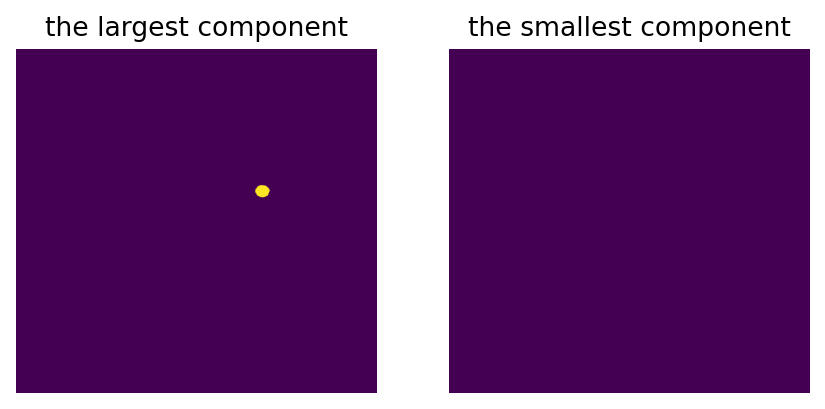

In [10]:
plt.figure(dpi=160)
plt.subplot(121)
plt.imshow(l==cc[ind_max,0])
plt.axis('off')
plt.title('the largest component')
plt.subplot(122)
plt.imshow(l==cc[ind_min,0])
plt.axis('off')
plt.title('the smallest component')
plt.show()